# Clustering por Densidad: DBSCAN y el Descubrimiento del Ruido

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/03_machine_learning/15_clustering_por_densidad_dbscan.ipynb)

## Objetivos


- Comprender el paradigma del clustering basado en densidad frente al basado en distancias al centroide.
- Implementar **DBSCAN** para descubrir clusters de formas arbitrarias (no lineales).
- **Criterio de Ingeniería:** Entender cómo DBSCAN maneja los valores atípicos (*outliers*) asignándoles la etiqueta de "Ruido" (`-1`), sentando las bases para la Detección de Anomalías.



## Prerrequisitos


- Entendimiento de las limitaciones geométricas de K-Means.
- Haber completado: [Clustering: Modelos Probabilísticos (GMM) y Jerárquicos](14_clustering_jerarquico_y_gmm.ipynb).

---



## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", f"https://github.com/AxelSkrauba/{REPO_NAME}.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")
else:
    # Repositorio en local, apuntar path a la raiz
    os.chdir(f"../../")

from utils.plots import setup_plot_style
setup_plot_style()

## Introducción Teórica



Hasta ahora, todos los algoritmos de clustering que vimos (K-Means, GMM, Jerárquico) comparten un defecto fundamental de diseño: **obligan a que cada punto pertenezca a un cluster**.

Si se tiene un dataset de clientes y hay un registro que es un error del sistema (un *outlier* extremo), K-Means lo meterá a la fuerza en el grupo más cercano. Esto desplazará el centroide de ese grupo, arruinando la segmentación para los clientes reales.

Además, ¿qué pasa si los datos no tienen forma de globo o elipse, sino que forman anillos concéntricos o masas amorfas?

### DBSCAN (Density-Based Spatial Clustering of Applications with Noise)



DBSCAN agrupa los datos de la misma forma en que lo hace el ojo humano: buscando áreas donde los puntos están muy concentrados y separándolas por áreas vacías.

Para funcionar, se deben definir dos hiperparámetros:
1. **`eps` (Epsilon):** El radio de búsqueda alrededor de un punto. (¿Qué tan lejos miro para buscar vecinos?).
2. **`min_samples`:** El número mínimo de puntos que deben estar dentro del radio `eps` para considerar que esa zona es un cluster denso.

Basado en esto, DBSCAN clasifica cada punto en una de tres categorías:
- **Punto Núcleo (*Core*):** Tiene al menos `min_samples` vecinos dentro de su radio `eps`. Es el corazón de un cluster.
- **Punto Frontera (*Border*):** No tiene suficientes vecinos para ser núcleo, pero está dentro del radio de un Punto Núcleo. Es el borde del cluster.
- **Punto de Ruido (*Noise*):** No es núcleo ni frontera. Está aislado. **DBSCAN le asigna la etiqueta `-1`.**

El siguiente gráfico, intenta ilustrar este proceso:

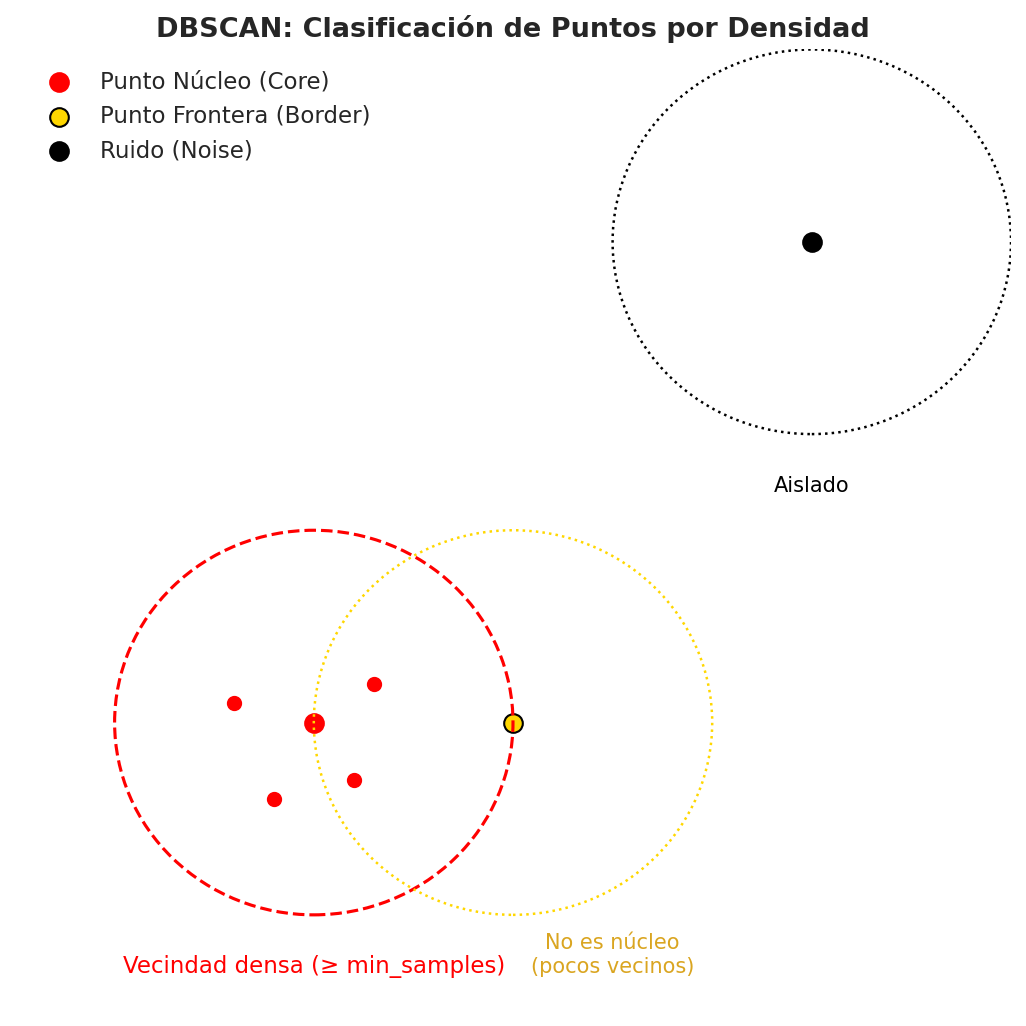

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 7))

# Punto núcleo (rojo)
core = np.array([0, 0])

# Vecinos dentro de eps
neighbors = np.array([
    [0.3, 0.2],
    [-0.4, 0.1],
    [0.2, -0.3],
    [-0.2, -0.4]
])

# Punto frontera (amarillo)
border = np.array([1.0, 0.0])

# Punto ruido (negro)
noise = np.array([2.5, 2.5])

# Radio eps
eps = 1.0

# ------------------------
# Dibujar puntos
# ------------------------

# Núcleo
ax.scatter(*core, color='red', s=80, label="Punto Núcleo (Core)")

# Vecinos
ax.scatter(neighbors[:, 0], neighbors[:, 1], color='red', s=40)

# Frontera
ax.scatter(*border, color='gold', edgecolor='black', s=80, label="Punto Frontera (Border)")

# Ruido
ax.scatter(*noise, color='black', s=80, label="Ruido (Noise)")

# ------------------------
# Dibujar círculos eps
# ------------------------

# Círculo del núcleo
circle_core = plt.Circle(core, eps, color='red', fill=False, linestyle='--', linewidth=1.5)
ax.add_patch(circle_core)

# Círculo del punto frontera
circle_border = plt.Circle(border, eps, color='gold', fill=False, linestyle=':', linewidth=1.2)
ax.add_patch(circle_border)

# Círculo del ruido
circle_noise = plt.Circle(noise, eps, color='black', fill=False, linestyle=':', linewidth=1.2)
ax.add_patch(circle_noise)

# ------------------------
# Anotaciones
# ------------------------

ax.text(0, -1.3, "Vecindad densa (≥ min_samples)", color='red', ha='center', fontsize=11)
ax.text(1.5, -1.3, "No es núcleo\n(pocos vecinos)", color='goldenrod', ha='center', fontsize=10)
ax.text(2.5, 1.2, "Aislado", color='black', ha='center', fontsize=10)


ax.set_title("DBSCAN: Clasificación de Puntos por Densidad", fontsize=13)
ax.set_xlim(-1.5, 3.5)
ax.set_ylim(-1.5, 3.5)
ax.set_xticks([])
ax.set_yticks([])

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

## Desarrollo e Implementación



Vamos a generar un dataset clásico en Machine Learning: las "Dos Lunas" (*Two Moons*), pero le añadimos un 10% de ruido estocástico para simular pequeños errores de medición o valores atípicos.

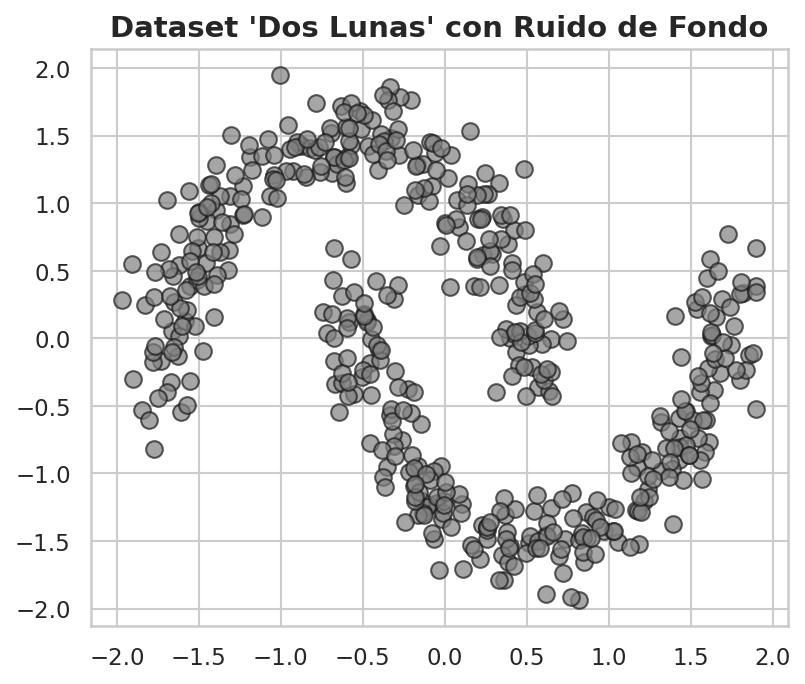

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# 1. Generamos el dataset de Dos Lunas con ruido
X, _ = make_moons(n_samples=500, noise=0.10, random_state=42)

# 2. Estandarización (CRÍTICO: DBSCAN mide distancias absolutas con 'eps')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualizamos el problema
plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c='gray', edgecolors='k', alpha=0.7)
plt.title("Dataset 'Dos Lunas' con Ruido de Fondo")
plt.show()

### El Fracaso de K-Means



Si le pedimos a K-Means que encuentre 2 clusters aquí, intentará encajar dos círculos rígidos.



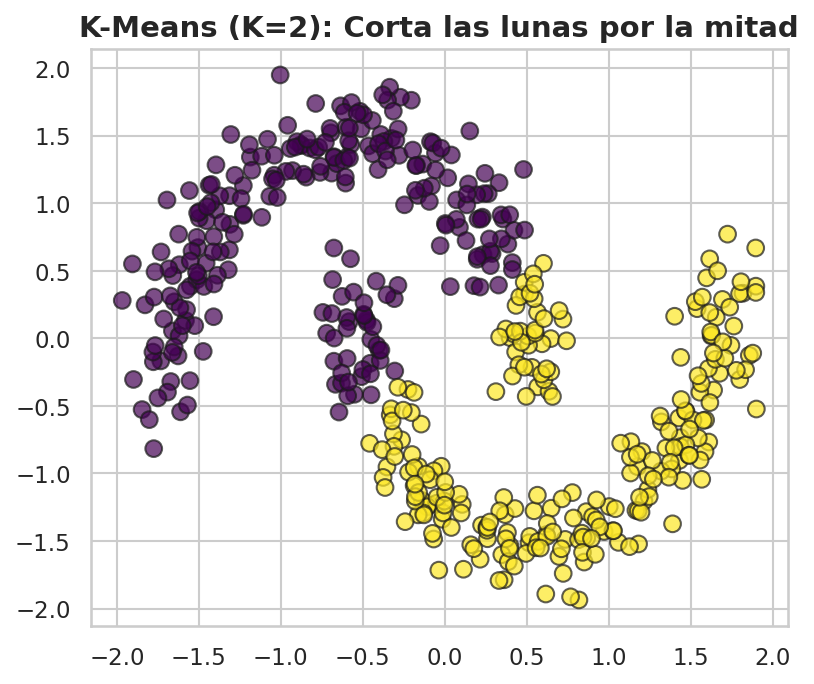

In [7]:
# Entrenamos K-Means
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, cmap='viridis', edgecolors='k', alpha=0.7)
plt.title("K-Means (K=2): Corta las lunas por la mitad")
plt.show()


Como era de esperar, K-Means destruye la topología natural de los datos. Además, los puntos de ruido que están flotando "lejos" fueron asignados a los clusters principales, contaminándolos.



### La Solución: DBSCAN


Ahora aplicamos DBSCAN. No le decimos **cuántos** clusters hay. Solo le decimos: *"Busca zonas donde haya al menos 5 puntos (`min_samples=5`) separados por una distancia máxima de 0.2 (`eps=0.2`)"*.

Clusters descubiertos automáticamente: 2
Puntos clasificados como Ruido (-1): 10


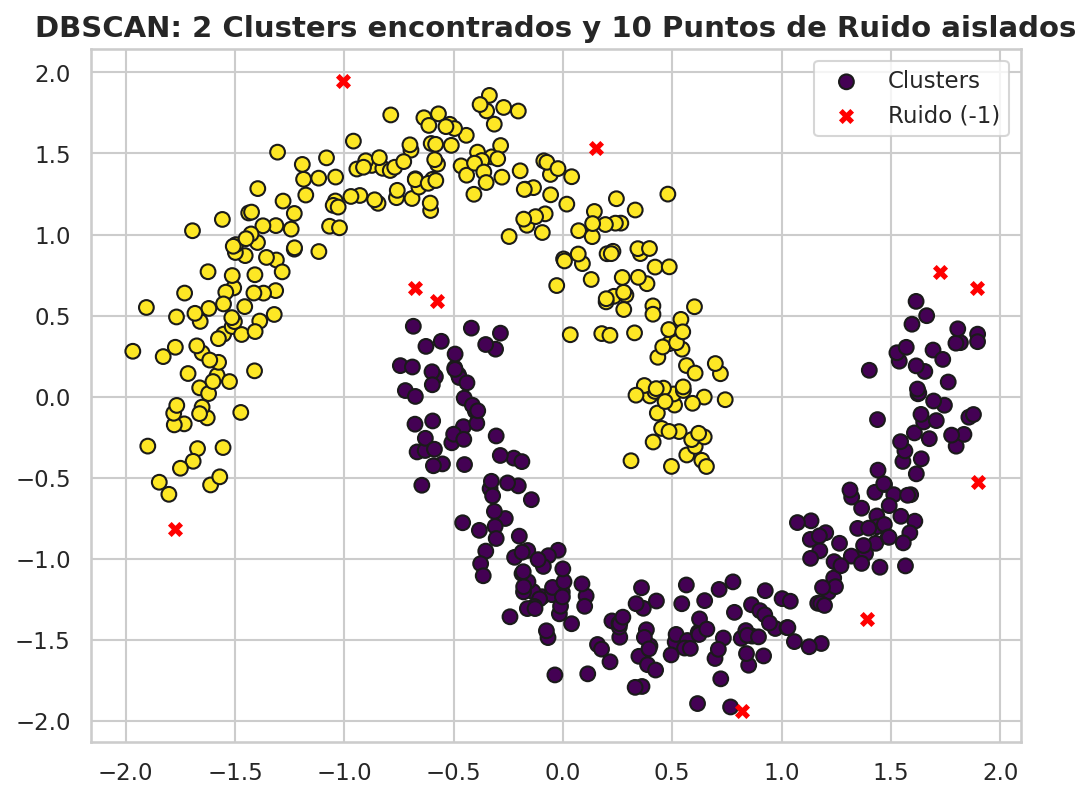

In [11]:
# Entrenamos DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)

# Extraemos el número de clusters encontrados (ignorando el ruido que es -1)
n_clusters = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
n_ruido = list(y_dbscan).count(-1)

print(f"Clusters descubiertos automáticamente: {n_clusters}")
print(f"Puntos clasificados como Ruido (-1): {n_ruido}")

# Visualización avanzada para destacar el ruido
plt.figure(figsize=(8, 6))

# Creamos una máscara para el ruido y otra para los clusters
mascara_ruido = (y_dbscan == -1)
mascara_clusters = (y_dbscan != -1)

# Graficamos los clusters normales
plt.scatter(X_scaled[mascara_clusters, 0], X_scaled[mascara_clusters, 1],
            c=y_dbscan[mascara_clusters], cmap='viridis', edgecolors='k', s=50, label='Clusters')

# Graficamos el ruido en color rojo y más pequeño
plt.scatter(X_scaled[mascara_ruido, 0], X_scaled[mascara_ruido, 1],
            c='red', marker='x', s=30, label='Ruido (-1)')

plt.title(f"DBSCAN: {n_clusters} Clusters encontrados y {n_ruido} Puntos de Ruido aislados")
plt.legend()
plt.show()

## Resultados y Discusión


¡El resultado es impecable (?)! DBSCAN logró dos hitos de ingeniería simultáneos:
1. **Descubrió la forma no lineal:** Identificó perfectamente las dos lunas sin que le dijéramos que $K=2$.
2. **Aisló las anomalías:** Observar las cruces rojas (`x`). DBSCAN detectó que esos puntos estaban demasiado aislados para pertenecer a una luna y los descartó, protegiendo la pureza de los clusters principales.

### El Reto de Ingeniería: Ajustar `eps`



DBSCAN parece mágico, pero tiene un talón de Aquiles: es extremadamente sensible al valor de `eps`.
- Si `eps` es muy pequeño, casi todo será clasificado como ruido (`-1`).
- Si `eps` es muy grande, todas las lunas y el ruido se fusionarán en un solo cluster gigante (`0`).

En la industria, para encontrar el `eps` óptimo, los ingenieros utilizan un gráfico de distancias a los K-vecinos más cercanos (K-distance graph), buscando el punto donde la distancia se dispara exponencialmente.

Además, DBSCAN sufre de la **Maldición de la Dimensionalidad**. Si se tienen 100 columnas, la distancia entre cualquier par de puntos tenderá a ser similar, haciendo casi imposible definir un `eps` que funcione. Por ello, **siempre se debe aplicar PCA o UMAP antes de usar DBSCAN en alta dimensionalidad.**

## Extra: Gráfico de Distancia a los K-Vecinos para Optimizar `eps`

Va un bosquejo para generar la gráfica que permite encontrar el `eps` óptimo.
La idea es encontrar la distancia promedio del k-ésimo vecino para cada punto en el dataset y graficarlas en orden ascendente. Un "codo" o punto de inflexión en este gráfico suele indicar un buen valor para `eps`.

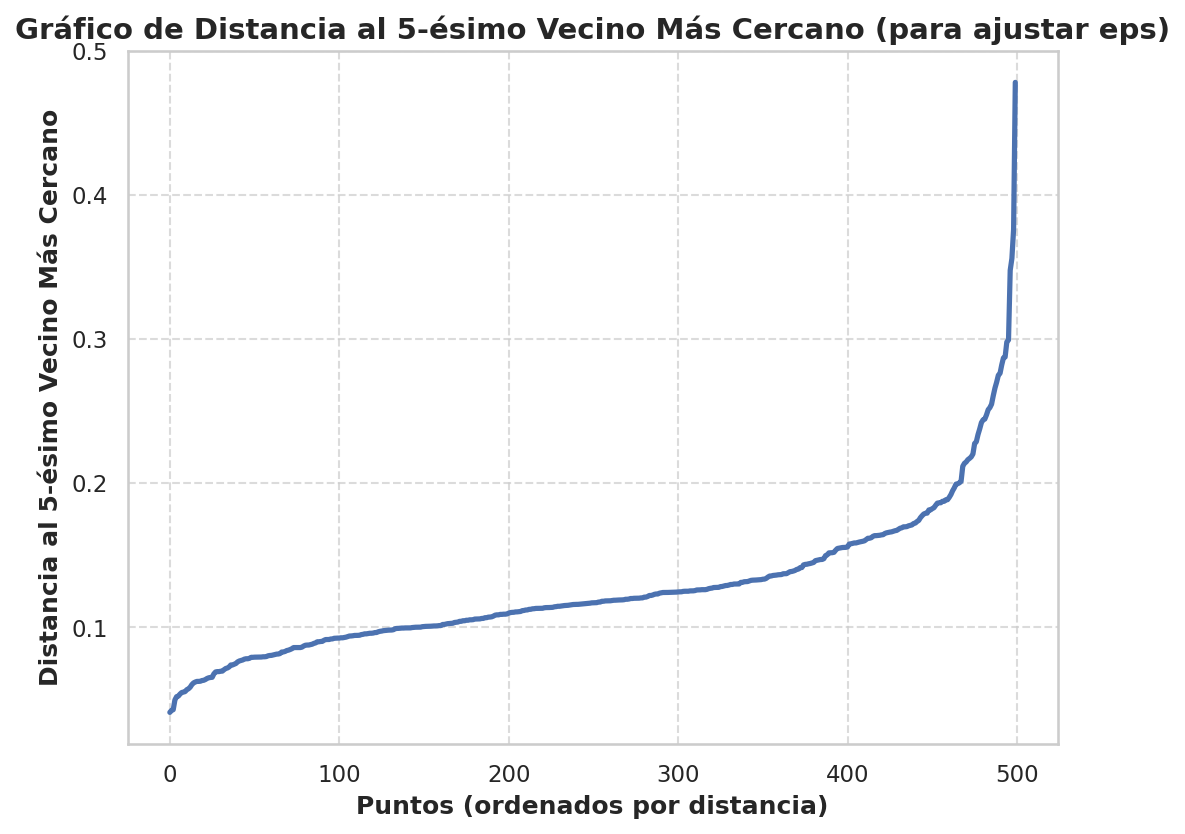

In [16]:
from sklearn.neighbors import NearestNeighbors

# min_samples es típicamente el k en k-distance graph
k = dbscan.min_samples

# Calculamos la distancia a los k vecinos más cercanos para cada punto
neigh = NearestNeighbors(n_neighbors=k)
neigh.fit(X_scaled)
distances, indices = neigh.kneighbors(X_scaled)

# Ordenamos las distancias del k-ésimo vecino
distances = np.sort(distances[:, k-1], axis=0)

# Graficamos
plt.figure(figsize=(8, 6))
plt.plot(distances)
plt.title(f'Gráfico de Distancia al {k}-ésimo Vecino Más Cercano (para ajustar eps)')
plt.xlabel('Puntos (ordenados por distancia)')
plt.ylabel(f'Distancia al {k}-ésimo Vecino Más Cercano')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Buscar el `codo` en el gráfico para un valor sugerido de `eps`.

Por ejemplo, un valor entre `0.15` y `0.25` podría ser un buen punto de partida para este dataset. Probar arriba (hiperparámetro de DBSCAN) y visualizar los cambios en las asignaciones de las muestras.

## Conexiones y Próximos Pasos



Con DBSCAN cerramos nuestro bloque de Clustering. Aprendimos a agrupar datos esféricos (K-Means), elípticos (GMM), jerárquicos (Aglomerativo) y de formas arbitrarias (DBSCAN). Aunque existen más algoritmos, estos sientan las bases para poder entenderlos.

A diferencia de los anteriores, DBSCAN nos dejó un regalo invaluable: la etiqueta `-1`. Nos demostró que a veces lo más interesante de un dataset no son los grupos normales, sino los puntos que no encajan en ningún lado.

- ➡️ **Siguiente:** En el notebook [Detección de Anomalías por Reconstrucción PCA](16_anomalias_por_reconstruccion_pca.ipynb), cambiamos nuestro objetivo. Dejamos de buscar la norma para empezar a cazar la excepción (fraudes bancarios, fallos de motores).
- 🔄 **Relacionado:** Si se quiere repasar por qué la alta dimensionalidad destruye los algoritmos basados en distancias como DBSCAN, volver al notebook [Reducción de Dimensionalidad (PCA)](11_pca_y_reconstruccion.ipynb).



## Referencias


1. Ester, M., Kriegel, H. P., Sander, J., & Xu, X. (1996). *A density-based algorithm for discovering clusters in large spatial databases with noise*. In kdd (Vol. 96, No. 34, pp. 226-231).
2. [Scikit-Learn: Demo of DBSCAN clustering algorithm](https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html)

---


## Entorno de Ejecución


In [12]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.13
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
